In [1]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 58 (delta 8), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (58/58), 163.32 MiB | 8.22 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (27/27), done.
Filtering content: 100% (12/12), 851.90 MiB | 22.00 MiB/s, done.
/content/PRMLProject


In [2]:
import numpy as np
from skimage.feature import hog
from tqdm import tqdm
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt

In [3]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data

In [4]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

In [5]:
X_train = [train_RawData.reshape(-1,3072),train_HoGData,train_PcaData,train_HoG_PcaData,train_Pca_HoGData]
y_train = train_labels
X_test = [test_RawData.reshape(-1,3072),test_HoGData,test_PcaData,test_HoG_PcaData,test_Pca_HoGData]
y_test = test_labels

In [6]:
print('Number of Training Samples ---> ',y_train.shape[0])
print('Dimensions of a Sample of RawData ---> ', X_train[0].shape[1])
print('Dimensions of a Sample of HoGData ---> ',X_train[1].shape[1])
print('Dimensions of a Sample of PCAData ---> ',X_train[2].shape[1])
print('Dimensions of a Sample of HoG_PCAData ---> ',X_train[3].shape[1])
print('Dimensions of a Sample of PCA_HoGData ---> ',X_train[4].shape[1])

Number of Training Samples --->  50000
Dimensions of a Sample of RawData --->  3072
Dimensions of a Sample of HoGData --->  324
Dimensions of a Sample of PCAData --->  658
Dimensions of a Sample of HoG_PCAData --->  170
Dimensions of a Sample of PCA_HoGData --->  324


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from tqdm import tqdm

def trainDecisionTree(X_train, y_train, max_depth, criterion):
    '''
      Fits a decision tree for the given data and impurity
    '''
    tree = DecisionTreeClassifier(criterion = criterion, max_depth=max_depth)
    tree.fit(X_train, y_train)
    return tree

def findMaxDepth(X_train, y_train, criterion):
    '''
      Finds the max_depth of the tree, that is the depth for which the tree is
      fully grown(train accuracy approaches 100%)
    '''
    print('Finding the max depth')
    max_depth = 100
    train_accuracies = []
    for depth in tqdm(range(1, max_depth)):
        tree = trainDecisionTree(X_train, y_train, depth, criterion)
        train_accuracy = tree.score(X_train, y_train)
        train_accuracies.append(train_accuracy)
        if train_accuracy >= 0.99:
            return depth, train_accuracies
    return max_depth, train_accuracies

def findOptimalDepth(X_train, y_train, criterion):
    '''
      Finds the optimal depth of the tree using GridSearchCV,
       to avoid overfitting
    '''
    max_depth, train_accuracies = findMaxDepth(X_train, y_train, criterion)
    param_grid = {'max_depth': list(range(1, max_depth + 1))}

    print('Finding Optimal depth')
    # Using 5 Fold Cross Validation
    grid_search = GridSearchCV(DecisionTreeClassifier(criterion=criterion), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search.best_params_['max_depth'], grid_search.best_score_, grid_search.cv_results_['mean_test_score'], train_accuracies,max_depth

def plot_accuracies_vs_depths(depths, train_accuracies, validation_accuracies, title_string,optimal_depth):
    '''
        Helping function to plot accuracy vs depth plots
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_accuracies, marker='o', linestyle='--', color='r', label='Training Accuracy')
    plt.plot(depths, validation_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
    plt.plot(optimal_depth, validation_accuracies[optimal_depth-1], marker='s', markersize=8, color='black')
    plt.plot(optimal_depth, train_accuracies[optimal_depth-1], marker='s', markersize=8, color='black')


    plt.xlabel('Depth')
    plt.ylabel('Accuracy')
    plt.title('Depth vs Accuracy ' + title_string)
    plt.xticks(depths)
    plt.legend()
    plt.show()

def DecisionTree(X_train, y_train, criterion):

    optimal_depth, best_score, validation_accuracies, train_accuracies, MaxDepth = findOptimalDepth(X_train, y_train, criterion)

    optimal_tree = trainDecisionTree(X_train, y_train, optimal_depth, criterion)

    return optimal_tree, optimal_depth, best_score, validation_accuracies, train_accuracies, MaxDepth

def predict(tree, X_test) :

    return tree.predict(X_test)

def testAccuracy(LabelsPrediction, LabelsActual) :

    return np.sum(LabelsPrediction == LabelsActual ) / len(LabelsActual)

In [8]:
OptimalTree_HoG_PCA, OptimalDepth_HoG_PCA, BestScore_HoG_PCA, Validation_HoG_PCA, Train_HoG_PCA, MaxDepth_HoG_PCA = DecisionTree(X_train[3], y_train, 'entropy')

Finding the max depth


 19%|█▉        | 19/99 [12:48<53:56, 40.46s/it]  

Finding Optimal depth


In [9]:
OptimalTree_HoG, OptimalDepth_HoG, BestScore_HoG, Validation_HoG, Train_HoG, MaxDepth_HoG = DecisionTree(X_train[1], y_train, 'entropy')

Finding the max depth


 21%|██        | 21/99 [26:12<1:37:19, 74.87s/it]

Finding Optimal depth


In [10]:
OptimalTree_PCA_HoG, OptimalDepth_PCA_HoG, BestScore_PCA_HoG, Validation_PCA_HoG, Train_PCA_HoG, MaxDepth_PCA_HoG = DecisionTree(X_train[4], y_train, 'entropy')

Finding the max depth


 20%|██        | 20/99 [24:56<1:38:29, 74.81s/it]

Finding Optimal depth


In [11]:
OptimalTree_PCA, OptimalDepth_PCA, BestScore_PCA, Validation_PCA, Train_PCA, MaxDepth_PCA = DecisionTree(X_train[2], y_train, 'entropy')

Finding the max depth


 22%|██▏       | 22/99 [58:56<3:26:16, 160.73s/it]

Finding Optimal depth


In [12]:
print('OptimalDepth of Tree for HoG_PCA -->',OptimalDepth_HoG_PCA)
print('OptimalDepth of Tree for HoG -->',OptimalDepth_HoG)
print('OptimalDepth of Tree for PCA_HoG -->',OptimalDepth_PCA_HoG)
print('OptimalDepth of Tree for PCA -->',OptimalDepth_PCA)

OptimalDepth of Tree for HoG_PCA --> 9
OptimalDepth of Tree for HoG --> 10
OptimalDepth of Tree for PCA_HoG --> 9
OptimalDepth of Tree for PCA --> 9


In [13]:
print('Best Validation accuracy for HoG_PCA -->',BestScore_HoG_PCA)
print('Best Validation accuracy for HoG -->',BestScore_HoG)
print('Best Validation accuracy for PCA_HoG -->',BestScore_PCA_HoG)
print('Best Validation accuracy for PCA -->',BestScore_PCA)

Best Validation accuracy for HoG_PCA --> 0.35218
Best Validation accuracy for HoG --> 0.30433999999999994
Best Validation accuracy for PCA_HoG --> 0.2681
Best Validation accuracy for PCA --> 0.30138


In [14]:
print('MaxDepth of Tree for HoG_PCA -->',MaxDepth_HoG_PCA)
print('MaxDepth of Tree for HoG -->',MaxDepth_HoG)
print('MaxDepth of Tree for PCA_HoG -->',MaxDepth_PCA_HoG)
print('MaxDepth of Tree for PCA -->',MaxDepth_PCA)

MaxDepth of Tree for HoG_PCA --> 20
MaxDepth of Tree for HoG --> 22
MaxDepth of Tree for PCA_HoG --> 21
MaxDepth of Tree for PCA --> 23


In [15]:
print('Average Validation accuracies for different depths using HoG_PCA --->',Validation_HoG_PCA)
print('Average Validation accuracies for different depths using HoG --->',Validation_HoG)
print('Average Validation accuracies for different depths using PCA_HoG --->',Validation_PCA_HoG)
print('Average Validation accuracies for different depths using PCA --->',Validation_PCA)

Average Validation accuracies for different depths using HoG_PCA ---> [0.17476 0.21708 0.25254 0.285   0.30842 0.32036 0.33556 0.34796 0.35218
 0.34786 0.33854 0.32818 0.3154  0.30574 0.29506 0.29398 0.28942 0.28704
 0.28888 0.28782]
Average Validation accuracies for different depths using HoG ---> [0.15334 0.1739  0.20152 0.234   0.24776 0.2687  0.2835  0.29658 0.30094
 0.30434 0.3033  0.29916 0.29106 0.28408 0.28132 0.2787  0.27502 0.27476
 0.27398 0.27384 0.2717  0.27122]
Average Validation accuracies for different depths using PCA_HoG ---> [0.15204 0.1696  0.19672 0.2133  0.23276 0.24714 0.25846 0.26506 0.2681
 0.26698 0.26564 0.26404 0.25896 0.25152 0.24862 0.24394 0.2426  0.2419
 0.24168 0.24142 0.24158]
Average Validation accuracies for different depths using PCA ---> [0.14742 0.18134 0.22022 0.2366  0.25672 0.27078 0.28742 0.29698 0.30138
 0.29262 0.28308 0.27212 0.26096 0.25618 0.25016 0.24534 0.24266 0.23886
 0.23882 0.23692 0.23488 0.23508 0.2352 ]


In [16]:
print('Training accuracies for different depths using HoG_PCA --->',Train_HoG_PCA)
print('Training accuracies for different depths using HoG --->',Train_HoG)
print('Training accuracies for different depths using PCA_HoG --->',Train_PCA_HoG)
print('Training accuracies for different depths using PCA --->',Train_PCA)

Training accuracies for different depths using HoG_PCA ---> [0.17514, 0.21904, 0.2557, 0.29002, 0.3147, 0.33262, 0.35958, 0.38642, 0.41186, 0.45174, 0.50792, 0.5807, 0.6635, 0.7537, 0.83214, 0.89512, 0.94098, 0.96968, 0.98544, 0.99358]
Training accuracies for different depths using HoG ---> [0.15344, 0.17328, 0.213, 0.23332, 0.25816, 0.28202, 0.3084, 0.3354, 0.36712, 0.41128, 0.46668, 0.5371, 0.61846, 0.70118, 0.77936, 0.84518, 0.89622, 0.93478, 0.96208, 0.9796, 0.98896, 0.99486]
Training accuracies for different depths using PCA_HoG ---> [0.15204, 0.17032, 0.20446, 0.22634, 0.25032, 0.2675, 0.29078, 0.31266, 0.33988, 0.38388, 0.44286, 0.51926, 0.60764, 0.69954, 0.78432, 0.85624, 0.90936, 0.94398, 0.96698, 0.98146, 0.99046]
Training accuracies for different depths using PCA ---> [0.14776, 0.18208, 0.22156, 0.2405, 0.26584, 0.28438, 0.30914, 0.33296, 0.3647, 0.40788, 0.46736, 0.54646, 0.63424, 0.72068, 0.79356, 0.84854, 0.8902, 0.92014, 0.94278, 0.96042, 0.97328, 0.98338, 0.99074]


In [17]:
Predictions_HoG_PCA = predict(OptimalTree_HoG_PCA, X_test[3])
Predictions_HoG = predict(OptimalTree_HoG, X_test[1])
Predictions_PCA_HoG = predict(OptimalTree_PCA_HoG, X_test[4])
Predictions_PCA = predict(OptimalTree_PCA, X_test[2])

In [18]:
testAccuracy_HoG_PCA = testAccuracy(Predictions_HoG_PCA, y_test)
testAccuracy_HoG = testAccuracy(Predictions_HoG, y_test)
testAccuracy_PCA_HoG = testAccuracy(Predictions_PCA_HoG, y_test)
testAccuracy_PCA = testAccuracy(Predictions_PCA, y_test)

In [19]:
print('Testing accuracy for HoG_PCA --->',testAccuracy_HoG_PCA)
print('Testing accuracy for HoG --->',testAccuracy_HoG)
print('Testing accuracy for PCA_HoG --->',testAccuracy_PCA_HoG)
print('Testing accuracy for PCA --->',testAccuracy_PCA)

Testing accuracy for HoG_PCA ---> 0.352
Testing accuracy for HoG ---> 0.3112
Testing accuracy for PCA_HoG ---> 0.269
Testing accuracy for PCA ---> 0.3096


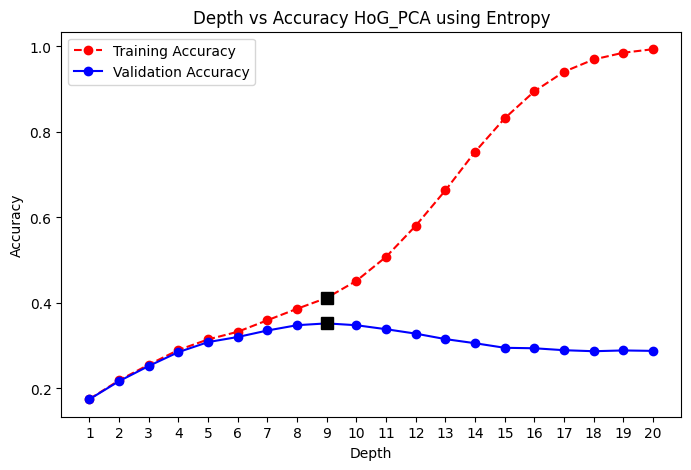

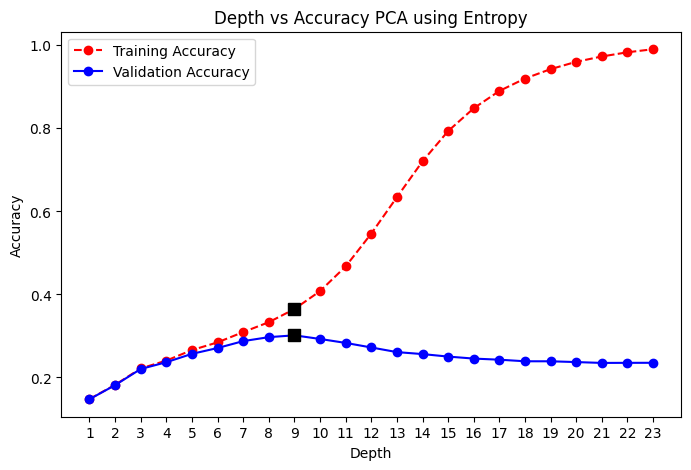

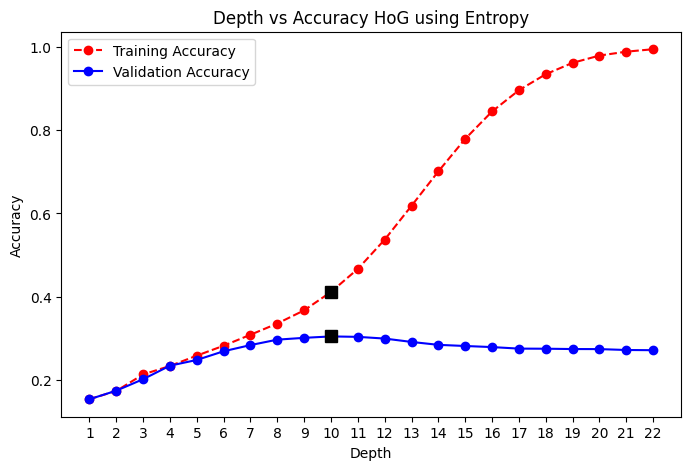

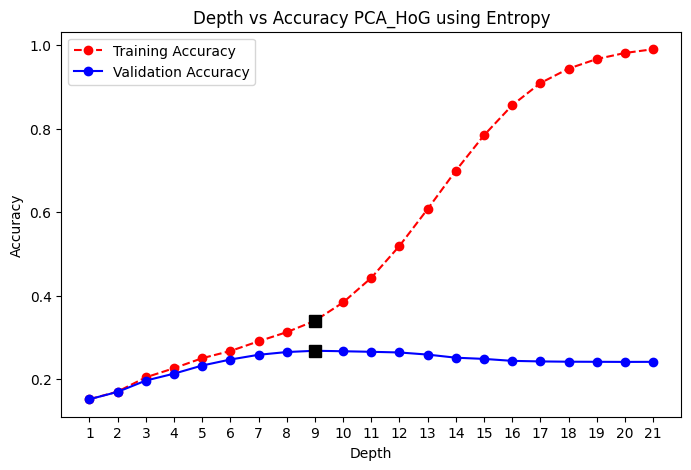

In [20]:
plot_accuracies_vs_depths(range(1, MaxDepth_HoG_PCA+1), Train_HoG_PCA, Validation_HoG_PCA, 'HoG_PCA using Entropy',OptimalDepth_HoG_PCA)
plot_accuracies_vs_depths(range(1, MaxDepth_PCA+1), Train_PCA, Validation_PCA, 'PCA using Entropy',OptimalDepth_PCA)
plot_accuracies_vs_depths(range(1, MaxDepth_HoG+1), Train_HoG, Validation_HoG, 'HoG using Entropy',OptimalDepth_HoG)
plot_accuracies_vs_depths(range(1, MaxDepth_PCA_HoG+1), Train_PCA_HoG, Validation_PCA_HoG, 'PCA_HoG using Entropy',OptimalDepth_PCA_HoG)

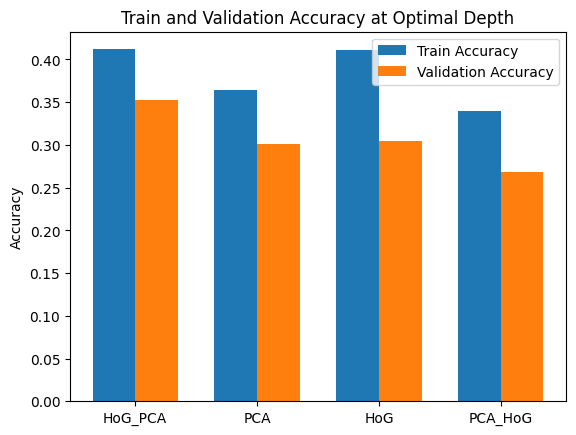

In [21]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['HoG_PCA', 'PCA', 'HoG', 'PCA_HoG']
optimal_depths = [OptimalDepth_HoG_PCA, OptimalDepth_PCA, OptimalDepth_HoG, OptimalDepth_PCA_HoG]
train_accuracies = [Train_HoG_PCA[OptimalDepth_HoG_PCA - 1], Train_PCA[OptimalDepth_PCA - 1], Train_HoG[OptimalDepth_HoG - 1], Train_PCA_HoG[OptimalDepth_PCA_HoG - 1]]
validation_accuracies = [Validation_HoG_PCA[OptimalDepth_HoG_PCA - 1], Validation_PCA[OptimalDepth_PCA - 1], Validation_HoG[OptimalDepth_HoG - 1], Validation_PCA_HoG[OptimalDepth_PCA_HoG - 1]]

bar_width = 0.35

fig, ax = plt.subplots()
bar1 = ax.bar(np.arange(len(datasets)), train_accuracies, bar_width, label='Train Accuracy')
bar2 = ax.bar(np.arange(len(datasets)) + bar_width, validation_accuracies, bar_width, label='Validation Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Train and Validation Accuracy at Optimal Depth')
ax.set_xticks(np.arange(len(datasets)) + bar_width / 2)
ax.set_xticklabels(datasets)
ax.legend()

plt.show()

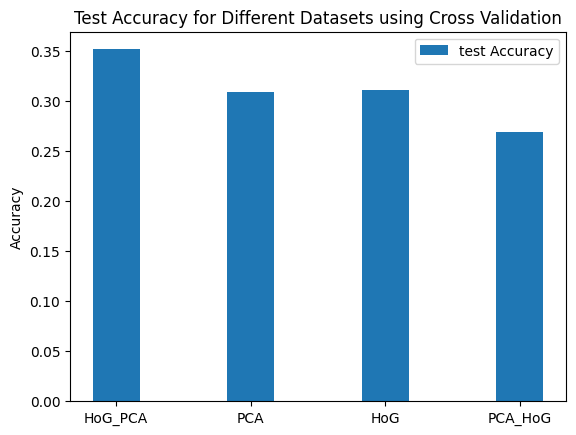

In [22]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['HoG_PCA', 'PCA', 'HoG', 'PCA_HoG']
testAccuracies = [testAccuracy_HoG_PCA, testAccuracy_PCA, testAccuracy_HoG, testAccuracy_PCA_HoG]
bar_width = 0.35

fig, ax = plt.subplots()
bar2 = ax.bar(np.arange(len(datasets)), testAccuracies, bar_width, label='test Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy for Different Datasets using Cross Validation')
ax.set_xticks(np.arange(len(datasets)))
ax.set_xticklabels(datasets)
ax.legend()

plt.show()